In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
print(os.getcwd())

c:\Users\priya\OneDrive\Desktop\NETWORKMED_PROJ\graph_network


In [3]:
ppi = pd.read_csv('../raw_data/protein_protein_link.txt.gz',sep=' ',compression='gzip')
ppi.head()

,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,311
1,9606.ENSP00000000233,9606.ENSP00000226004,161
2,9606.ENSP00000000233,9606.ENSP00000434442,499
3,9606.ENSP00000000233,9606.ENSP00000262455,531
4,9606.ENSP00000000233,9606.ENSP00000303145,499


In [4]:
p_info = pd.read_csv('../raw_data/protein_info.txt.gz',sep='\t',compression='gzip')
p_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


In [5]:
name_map = p_info.set_index('#string_protein_id')['preferred_name']

In [6]:
ppi = ppi[ppi['combined_score']>=900]

In [7]:
ppi['protein1'] = ppi['protein1'].map(name_map)
ppi['protein2'] = ppi['protein2'].map(name_map)

ppi.head()

,protein1,protein2,combined_score
155,M6PR,IGF2R,900
210,M6PR,GGA3,970
254,FKBP4,PGR,926
272,FKBP4,FKBP5,970
283,FKBP4,HSP90AB1,995


In [8]:
import networkx as nx
import matplotlib.pyplot as plt


In [9]:
G = nx.from_pandas_edgelist(ppi, 
                            source='protein1', 
                            target='protein2', 
                            edge_attr='combined_score')

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 8706
Edges: 44931


In [10]:
# plt.figure(figsize=(10, 8))

# # Use a spring layout to spread out the nodes
# pos = nx.spring_layout(G, k=0.5) 

# # Draw nodes and labels
# nx.draw(G, pos, with_labels=True, 
#         node_color='skyblue', 
#         node_size=800, 
#         font_size=10, 
#         edge_color='gray',
#         alpha=0.8)

# plt.title("Protein-Protein Interaction Network")
# plt.show()

it is not pssible to see grpah as number of nodes and edges are high , so we make only for one protein

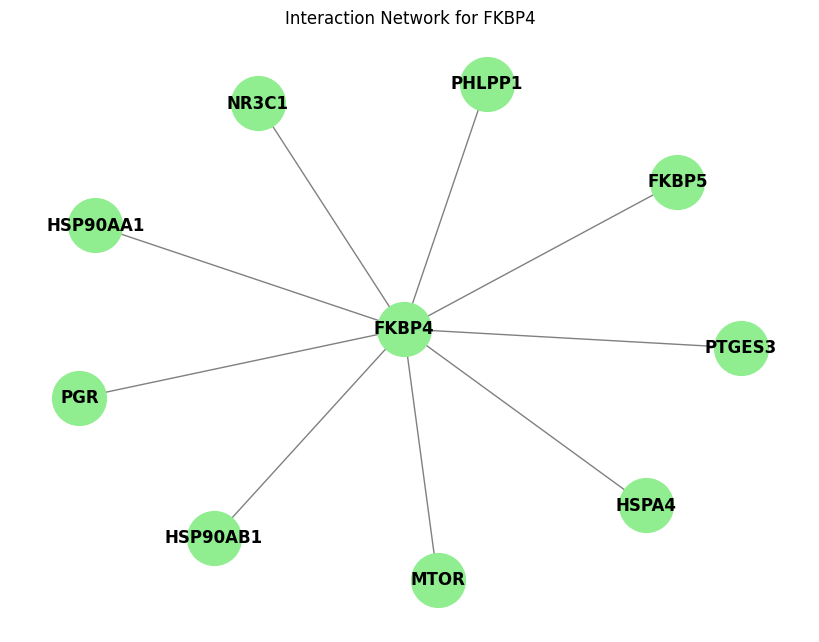

In [11]:

# 1. Pick your protein of interest
target_protein = 'FKBP4'

# 2. Find all rows where this protein appears
subset_df = ppi[(ppi['protein1'] == target_protein) | (ppi['protein2'] == target_protein)]

# 3. (Optional) Filter for strength so we don't get too many neighbors
# Let's take the top 20 strongest interactions for this protein
subset_df = subset_df.nlargest(20, 'combined_score')

# 4. Create the small graph
G_small = nx.from_pandas_edgelist(subset_df, 'protein1', 'protein2', 'combined_score')

# 5. Draw it
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_small, k=0.8) # k increases distance between nodes

nx.draw(G_small, pos, 
        with_labels=True, 
        node_color='lightgreen', 
        node_size=1500, 
        font_weight='bold',
        edge_color='gray')

plt.title(f"Interaction Network for {target_protein}")
plt.show()

In [12]:
degree_dict = dict(G.degree())
print(degree_dict)  

{'M6PR': 2, 'IGF2R': 8, 'GGA3': 9, 'FKBP4': 9, 'PGR': 8, 'FKBP5': 10, 'HSP90AB1': 59, 'HSP90AA1': 67, 'MTOR': 26, 'PHLPP1': 4, 'PTGES3': 33, 'HSPA4': 37, 'NR3C1': 11, 'CYP26B1': 2, 'CYP26A1': 2, 'CYP26C1': 2, 'FUCA2': 1, 'FUCA1': 1, 'SEMA3F': 4, 'PLXNA1': 8, 'NRP1': 23, 'NRP2': 13, 'PLXNA3': 6, 'CFTR': 8, 'TJP1': 51, 'YWHAB': 13, 'FLNA': 20, 'YWHAG': 11, 'YWHAZ': 23, 'SLC9A3R1': 10, 'GOPC': 2, 'USP28': 6, 'TP53BP1': 55, 'UBB': 168, 'UBC': 172, 'FBXW7': 14, 'RPS27A': 255, 'UBA52': 235, 'HSPB6': 1, 'SFN': 24, 'USH1C': 5, 'ANKS4B': 1, 'CDH23': 3, 'MYO7B': 1, 'USH1G': 2, 'MYO7A': 4, 'RALA': 5, 'RALBP1': 2, 'EXOC2': 11, 'RASA1': 9, 'EXOC8': 11, 'RALB': 4, 'CACNG3': 12, 'CACNG8': 15, 'CACNB4': 13, 'CACNB3': 15, 'CACNA2D4': 12, 'CACNA1D': 14, 'CACNA1C': 23, 'CACNG4': 12, 'CACNA1F': 12, 'CACNG7': 12, 'CACNA2D1': 16, 'CACNA1S': 20, 'CACNG6': 12, 'DVL2': 27, 'PRICKLE2': 5, 'PRICKLE1': 5, 'LRP6': 23, 'VANGL2': 10, 'FRAT2': 5, 'ARRB2': 23, 'AXIN1': 28, 'CSNK1E': 15, 'FRAT1': 6, 'CSNK2A2': 7, 'CSNK

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Step 1: Calculating Network Features (this may take a minute)...")

# 1. Calculate various centrality measures (Our Features X)
# We use 'k' to speed up betweenness by sampling 500 random nodes
betweenness = nx.betweenness_centrality(G, k=500, normalized=True)
pagerank = nx.pagerank(G)
clustering = nx.clustering(G)
closeness = nx.closeness_centrality(G) # How 'central' it is to everyone

# 2. Get Degree for our Label (Y)
degree_dict = dict(G.degree())

# 3. Com# 1. Create the DataFrame
# By passing list(G.nodes()) as the index, we ensure every row has its protein name
ml_df = pd.DataFrame({
    'betweenness': pd.Series(betweenness),
    'pagerank': pd.Series(pagerank),
    'clustering': pd.Series(clustering),
    'closeness': pd.Series(closeness),
    'raw_degree': pd.Series(degree_dict)
}, index=list(G.nodes())).fillna(0) # <--- ADDED index=list(G.nodes())

# 2. Add your ML results back into this named dataframe
X_all = ml_df[['betweenness', 'pagerank', 'clustering', 'closeness']]
X_all_scaled = scaler.transform(X_all)
ml_df['risk_score'] = rf_model.predict_proba(X_all_scaled)[:, 1]

# 3. Save it - making sure we keep the index (the names)
ml_df.to_csv('protein_features_database.csv', index=True)

# 4. FINAL TEST: This should now print names, not numbers
print("Verification - Row Names:")
print(ml_df.index[:5].tolist())

Step 1: Calculating Network Features (this may take a minute)...


NameError: name 'scaler' is not defined

In [ ]:
G.size()

44931

In [ ]:
# Define Features (X) and Target (y)
X = ml_df.drop(columns=['is_high_risk', 'raw_degree'])
y = ml_df['is_high_risk']

# 1. Split into Train (80%) and Test (20%)
# We use stratify to ensure both sets have the same ratio of High-Risk proteins
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Feature Scaling
# Network metrics have very different scales (e.g., PageRank is tiny, Closeness is larger)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStep 2: Data Splitting and Scaling Complete.")
print(f"Training shape: {X_train_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")


Step 2: Data Splitting and Scaling Complete.
Training shape: (6964, 4)
Testing shape: (1742, 4)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the Model
# n_estimators=100 means we are using 100 'Decision Trees' to vote on the answer
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model
print("Training the Random Forest model...")
rf_model.fit(X_train_scaled, y_train)

# 3. Make Predictions on the Test Set
y_pred = rf_model.predict(X_test_scaled)

# 4. Display Results
print("\n" + "="*30)
print("   MODEL PERFORMANCE REPORT")
print("="*30)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Metrics:")
print(classification_report(y_test, y_pred))

Training the Random Forest model...

   MODEL PERFORMANCE REPORT
Overall Accuracy: 97.59%

Detailed Metrics:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1556
           1       0.92      0.84      0.88       186

    accuracy                           0.98      1742
   macro avg       0.95      0.92      0.93      1742
weighted avg       0.98      0.98      0.98      1742



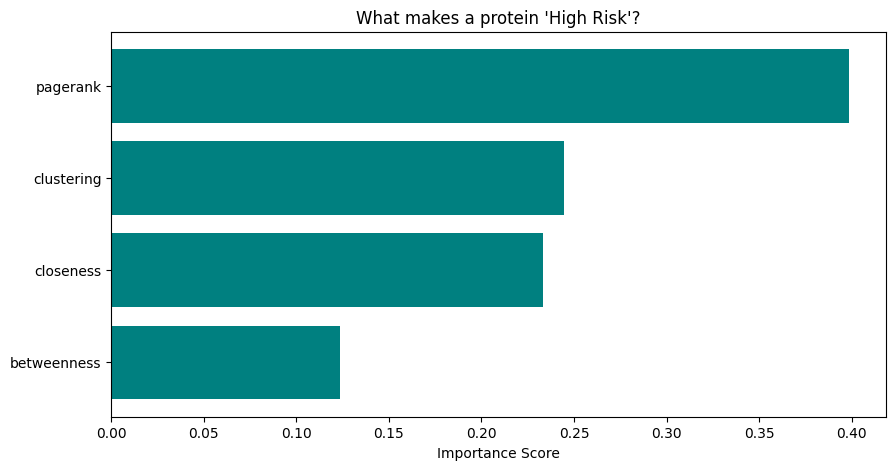

In [ ]:
import numpy as np

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title("What makes a protein 'High Risk'?")
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Importance Score')
plt.show()

In [ ]:
import joblib
import pickle
import pandas as pd
import networkx as nx

# 1. Save the model
joblib.dump(rf_model, 'protein_risk_model.pkl')

# 2. Save the scaler (crucial for getting the math right on the website)
joblib.dump(scaler, 'scaler.pkl')

# 3. Save the ml_df (so the website can look up the features)
ml_df.to_csv('protein_features_database.csv', index=False)

# 4. Save your graph (Updated for NetworkX 3.0+)
# We use the pickle module directly since nx.write_gpickle is deprecated
with open("human_interactome.gpickle", "wb") as f:
    pickle.dump(G, f)

print("All files saved successfully.")

All files saved successfully.


In [ ]:
import streamlit as st
import pandas as pd
import joblib

st.title("🧬 Network Medicine: Protein Toxicity Predictor")

# Load your saved data
model = joblib.load('protein_risk_model.pkl')
data = pd.read_csv('protein_features_database.csv', index_col=0)

protein_input = st.text_input("Enter Protein Name (e.g., M6PR):", "M6PR")

if st.button('Analyze Risk'):
    if protein_input in data.index:
        # Get risk probability
        prob = data.loc[protein_input, 'risk_score']
        
        # Display a nice visual
        st.metric(label="Toxicity Risk Probability", value=f"{prob*100:.2f}%")
        
        if prob > 0.5:
            st.error("⚠️ HIGH RISK: This protein is a major network hub.")
        else:
            st.success("✅ LOW RISK: This protein is peripherally located.")
    else:
        st.write("Protein not found in our interactome database.")

2026-04-13 01:34:32.719 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 01:34:32.721 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-13 01:34:32.722 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


FileNotFoundError: [Errno 2] No such file or directory: 'protein_risk_model.pkl'

In [ ]:
import pandas as pd
temp_df = pd.read_csv('protein_features_database.csv')
print(temp_df.columns.tolist())
print(temp_df.head(2))

['betweenness', 'pagerank', 'clustering', 'closeness', 'raw_degree', 'is_high_risk', 'risk_score']
   betweenness  pagerank  clustering  closeness  raw_degree  is_high_risk  \
0     0.000000  0.000044    1.000000   0.155084           2             0   
1     0.000202  0.000138    0.142857   0.171321           8             0   

   risk_score  
0        0.00  
1        0.02  


In [ ]:
import pandas as pd
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# --- PART 1: FEATURE CALCULATION ---
print("Step 1: Calculating Network Features...")
betweenness = nx.betweenness_centrality(G, k=500, normalized=True)
pagerank = nx.pagerank(G)
clustering = nx.clustering(G)
closeness = nx.closeness_centrality(G) 
degree_dict = dict(G.degree())

# Create DataFrame with names as the index
ml_df = pd.DataFrame({
    'betweenness': pd.Series(betweenness),
    'pagerank': pd.Series(pagerank),
    'clustering': pd.Series(clustering),
    'closeness': pd.Series(closeness),
    'raw_degree': pd.Series(degree_dict)
}, index=list(G.nodes())).fillna(0)

# Create the Label (y)
threshold = ml_df['raw_degree'].quantile(0.90)
ml_df['is_high_risk'] = (ml_df['raw_degree'] >= threshold).astype(int)

# --- PART 2: ML TRAINING ---
print("Step 2: Training the Model...")
X = ml_df[['betweenness', 'pagerank', 'clustering', 'closeness']]
y = ml_df['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# --- PART 3: FINAL DATABASE GENERATION ---
print("Step 3: Saving Final Database...")

# Now that rf_model exists, we can calculate the risk_score for the whole table
X_all_scaled = scaler.transform(X)
ml_df['risk_score'] = rf_model.predict_proba(X_all_scaled)[:, 1]

# Save everything
ml_df.to_csv('protein_features_database.csv', index=True)
import joblib
joblib.dump(rf_model, 'protein_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n--- ALL DONE ---")
print("Verification - Row Names:")
print(ml_df.index[:5].tolist())

Step 1: Calculating Network Features...
Step 2: Training the Model...
Step 3: Saving Final Database...

--- ALL DONE ---
Verification - Row Names:
['M6PR', 'IGF2R', 'GGA3', 'FKBP4', 'PGR']


In [14]:
import pandas as pd
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# --- PART 1: FEATURE CALCULATION ---
print("Step 1: Calculating Network Features...")
betweenness = nx.betweenness_centrality(G, k=500, normalized=True)
pagerank = nx.pagerank(G)
clustering = nx.clustering(G)
closeness = nx.closeness_centrality(G) 
degree_dict = dict(G.degree())

# Create DataFrame with names as the index
ml_df = pd.DataFrame({
    'betweenness': pd.Series(betweenness),
    'pagerank': pd.Series(pagerank),
    'clustering': pd.Series(clustering),
    'closeness': pd.Series(closeness),
    'raw_degree': pd.Series(degree_dict)
}, index=list(G.nodes())).fillna(0)

# Create the Label (y)
threshold = ml_df['raw_degree'].quantile(0.90)
ml_df['is_high_risk'] = (ml_df['raw_degree'] >= threshold).astype(int)

# --- PART 2: ML TRAINING ---
print("Step 2: Training the Model...")
X = ml_df[['betweenness', 'pagerank', 'clustering', 'closeness']]
y = ml_df['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# --- PART 3: FINAL DATABASE GENERATION ---
print("Step 3: Saving Final Database...")

# Now that rf_model exists, we can calculate the risk_score for the whole table
X_all_scaled = scaler.transform(X)
ml_df['risk_score'] = rf_model.predict_proba(X_all_scaled)[:, 1]

# Save everything
ml_df.to_csv('protein_features_database.csv', index=True)
import joblib
joblib.dump(rf_model, 'protein_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\n--- ALL DONE ---")
print("Verification - Row Names:")
print(ml_df.index[:5].tolist())

Step 1: Calculating Network Features...
Step 2: Training the Model...
Step 3: Saving Final Database...

--- ALL DONE ---
Verification - Row Names:
['M6PR', 'IGF2R', 'GGA3', 'FKBP4', 'PGR']


In [ ]:
# Find the biggest hub to test the website
biggest_hub = ml_df['raw_degree'].idxmax()
print(f"Try searching for this on your website: {biggest_hub}")

Try searching for this on your website: RPS27A


In [15]:
# Search for proteins with a risk score between 20% and 80%
nuanced_proteins = ml_df[(ml_df['risk_score'] > 0.2) & (ml_df['risk_score'] < 0.8)]

if not nuanced_proteins.empty:
    print("Try these proteins on your website for a number between 1 and 99:")
    print(nuanced_proteins.index.tolist()[:10])
else:
    print("The model is very certain (all 0s and 1s).")
    print("Let's look at the proteins with medium degrees instead:")
    # Look for proteins with 15-30 connections
    medium_degree = ml_df[(ml_df['raw_degree'] > 15) & (ml_df['raw_degree'] < 40)]
    print(medium_degree.index.tolist()[:10])

Try these proteins on your website for a number between 1 and 99:
['MTOR', 'NRP1', 'SFN', 'LRP6', 'ARRB2', 'ITGA4', 'ITGA5', 'CCR2', 'STIP1', 'DNAJC9']
